NORMAL DISTRIBUTION
--------------------------------------------------
Mean = 50
Standard Deviation = 10
x = 60
Fraction below x = 84.1345%


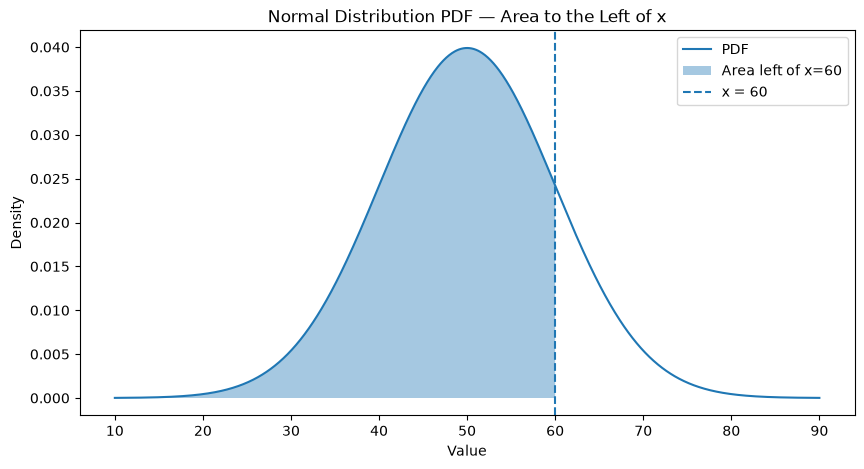

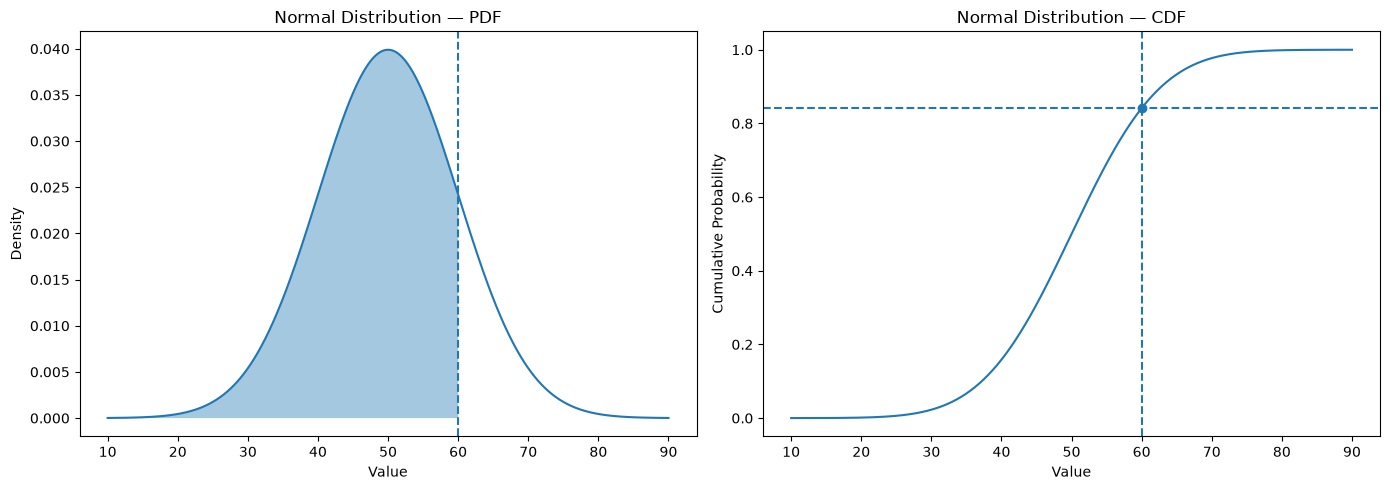


AREA VS CDF
--------------------------------------------------
Area under PDF to the left of 60: 0.841345
CDF at 60:                    0.841345
Difference:                          0.0000000000

PROBABILITY QUESTIONS
--------------------------------------------------
Fraction below x=60: 84.1345%
Fraction below mean=50:  50.0000%
Fraction above x=60: 15.8655%

90TH PERCENTILE
--------------------------------------------------
90th percentile = 62.8155
CDF at 90th percentile = 90.0000%


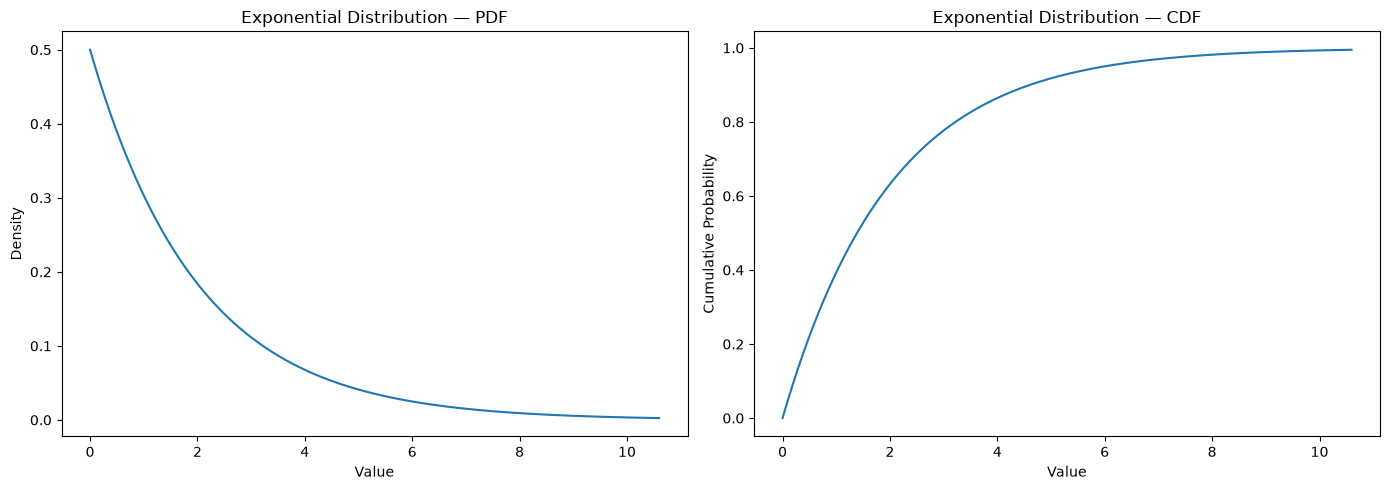

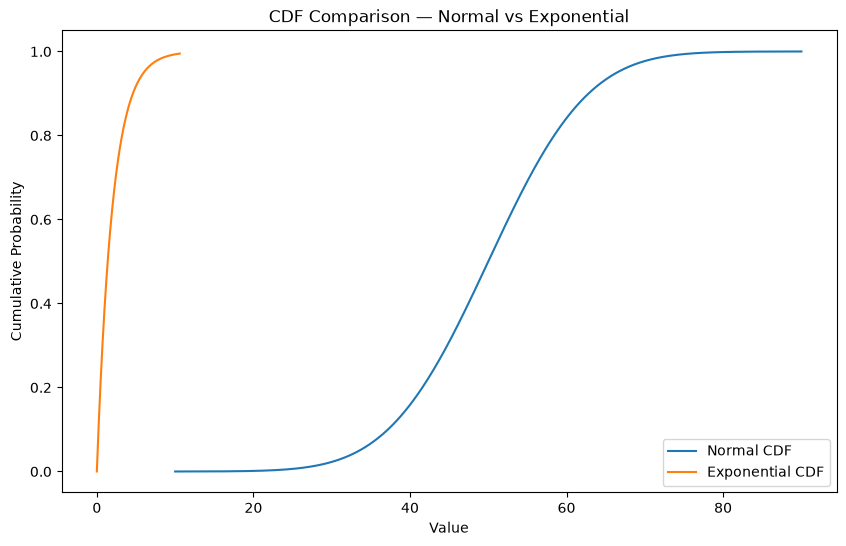

In [1]:
# TASK 04 — PDF AND CDF

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. NORMAL DISTRIBUTION

# Choose a normal distribution with mean = 50 and SD = 10
mu = 50
sigma = 10

# Create x-values across the distribution
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 1000)

# PDF = probability density at each x
pdf = stats.norm.pdf(x, loc=mu, scale=sigma)

# CDF = probability of getting a value <= x
cdf = stats.norm.cdf(x, loc=mu, scale=sigma)

# 2. CHOOSE A VALUE x

# We will investigate the probability of being below x = 60
x_value = 60

# CDF directly gives P(X <= 60)
cdf_value = stats.norm.cdf(
    x_value,
    loc=mu,
    scale=sigma
)

print("NORMAL DISTRIBUTION")
print("-" * 50)
print(f"Mean = {mu}")
print(f"Standard Deviation = {sigma}")
print(f"x = {x_value}")
print(f"Fraction below x = {cdf_value:.4%}")

# 3. AREA UNDER PDF TO THE LEFT OF x

# Create x-values only up to our chosen x.
x_shade = np.linspace(mu - 4 * sigma, x_value, 500)

# Calculate the PDF for those values.
pdf_shade = stats.norm.pdf(
    x_shade,
    loc=mu,
    scale=sigma
)

# Shade the area under the PDF.
# This area represents P(X <= x).
plt.figure(figsize=(10, 5))

plt.plot(x, pdf, label="PDF")

plt.fill_between(
    x_shade,
    pdf_shade,
    alpha=0.4,
    label=f"Area left of x={x_value}"
)

plt.axvline(
    x_value,
    linestyle="--",
    label=f"x = {x_value}"
)

plt.title("Normal Distribution PDF — Area to the Left of x")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

# 4. PDF AND CDF SIDE BY SIDE

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PDF
axes[0].plot(x, pdf)
axes[0].fill_between(
    x_shade,
    pdf_shade,
    alpha=0.4
)
axes[0].axvline(
    x_value,
    linestyle="--"
)
axes[0].set_title("Normal Distribution — PDF")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Density")


# CDF
axes[1].plot(x, cdf)
axes[1].axvline(
    x_value,
    linestyle="--"
)
axes[1].axhline(
    cdf_value,
    linestyle="--"
)
axes[1].scatter(
    [x_value],
    [cdf_value]
)
axes[1].set_title("Normal Distribution — CDF")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Cumulative Probability")

plt.tight_layout()
plt.show()

# 5. VERIFY AREA = CDF VALUE

# Numerical integration calculates the area under the PDF.
area_left = stats.norm.cdf(
    x_value,
    loc=mu,
    scale=sigma
)

print("\nAREA VS CDF")
print("-" * 50)
print(f"Area under PDF to the left of {x_value}: {area_left:.6f}")
print(f"CDF at {x_value}:                    {cdf_value:.6f}")
print(f"Difference:                          {abs(area_left - cdf_value):.10f}")

# 6. PROBABILITY QUESTIONS USING CDF

# Fraction below x
below_x = stats.norm.cdf(
    x_value,
    loc=mu,
    scale=sigma
)

# Fraction below the mean
below_mean = stats.norm.cdf(
    mu,
    loc=mu,
    scale=sigma
)

# Fraction above x
above_x = 1 - below_x

print("\nPROBABILITY QUESTIONS")
print("-" * 50)
print(f"Fraction below x={x_value}: {below_x:.4%}")
print(f"Fraction below mean={mu}:  {below_mean:.4%}")
print(f"Fraction above x={x_value}: {above_x:.4%}")


# 7. 90TH PERCENTILE USING INVERSE CDF (PPF)

# ppf is the inverse of the CDF.
# It answers: "What x-value has 90% below it?"
p90 = stats.norm.ppf(
    0.90,
    loc=mu,
    scale=sigma
)

print("\n90TH PERCENTILE")
print("-" * 50)
print(f"90th percentile = {p90:.4f}")

# Verify the result by putting it back into the CDF.
verification = stats.norm.cdf(
    p90,
    loc=mu,
    scale=sigma
)

print(f"CDF at 90th percentile = {verification:.4%}")


# 8. EXPONENTIAL DISTRIBUTION

# Use a skewed exponential distribution.
scale_exp = 2

x_exp = np.linspace(
    0,
    stats.expon.ppf(0.995, scale=scale_exp),
    1000
)

pdf_exp = stats.expon.pdf(
    x_exp,
    scale=scale_exp
)

cdf_exp = stats.expon.cdf(
    x_exp,
    scale=scale_exp
)


# PDF + CDF for exponential
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Exponential PDF
axes[0].plot(x_exp, pdf_exp)
axes[0].set_title("Exponential Distribution — PDF")
axes[0].set_xlabel("Value")
axes[0].set_ylabel("Density")


# Exponential CDF
axes[1].plot(x_exp, cdf_exp)
axes[1].set_title("Exponential Distribution — CDF")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Cumulative Probability")

plt.tight_layout()
plt.show()

# 9. COMPARE NORMAL AND EXPONENTIAL CDF SHAPES

plt.figure(figsize=(10, 6))

plt.plot(
    x,
    cdf,
    label="Normal CDF"
)

plt.plot(
    x_exp,
    cdf_exp,
    label="Exponential CDF"
)

plt.title("CDF Comparison — Normal vs Exponential")
plt.xlabel("Value")
plt.ylabel("Cumulative Probability")
plt.legend()

plt.show()

# TASK 04 — PDF AND CDF

PDF and CDF are two different ways of describing a probability distribution.

- **PDF (Probability Density Function)** shows the density/shape of a continuous distribution.
- **CDF (Cumulative Distribution Function)** shows the probability that a value is less than or equal to a given value.

We investigate both the **Normal** and **Exponential** distributions.


# 1. Normal Distribution Used

We use:

- Mean (μ) = 50
- Standard deviation (σ) = 10
- Chosen value x = 60

Therefore:

x = 60 is exactly one standard deviation above the mean.

z = (60 - 50) / 10

z = 1

# 2. What is a PDF?

PDF stands for:

**Probability Density Function**

For a continuous distribution, the PDF describes how probability density is distributed across possible values.

Important:

> The height of the PDF at one exact point is NOT the probability of that exact value.

Instead:

> The area under the PDF between two values represents the probability of falling within that interval.

For example:

The area under the normal PDF to the left of x = 60 represents:

P(X ≤ 60)

# 3. What is a CDF?

CDF stands for:

**Cumulative Distribution Function**

The CDF at a value x gives:

P(X ≤ x)

In simple words:

> CDF(x) tells us what fraction of observations are less than or equal to x.

# 4. Area Under PDF = CDF

For x = 60:

P(X ≤ 60) = CDF(60)

Using scipy:

stats.norm.cdf(60, loc=50, scale=10)

This gives approximately:

84.13%

Therefore:

> The area under the PDF to the left of 60 is approximately 84.13%, and the height of the CDF at 60 is also approximately 84.13%.

This verifies the relationship:

Area under PDF from -∞ to x = CDF(x)

# 5. Probability Questions

## What fraction of values fall below x = 60?

P(X ≤ 60)

≈ 84.13%

Therefore:

**Approximately 84.13% of values are below 60.**

## What fraction of values fall below the mean?

The mean is:

μ = 50

For a normal distribution, the mean is exactly at the centre.

Therefore:

P(X ≤ 50) = 0.5

= 50%

So:

**50% of values fall below the mean.**

## What fraction of values are above x = 60?

We know:

P(X ≤ 60) ≈ 0.8413

Therefore:

P(X > 60)

= 1 - P(X ≤ 60)

= 1 - 0.8413

≈ 0.1587

Therefore:

**Approximately 15.87% of values are above 60.**

# 6. 90th Percentile

A percentile answers:

> "What value has a certain percentage of observations below it?"

The 90th percentile means:

**90% of observations are below this value.**

We use:

python
stats.norm.ppf(0.90, loc=50, scale=10)